In [1]:
import os
from time import time
from tqdm import tqdm
from typing import *
import torch
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import delu

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_swiss_roll, make_gaussian_quantiles
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, QuantileTransformer

# from tqdm import tqdm
from copy import deepcopy

import numpy as np
import pandas as pd
from flow_matching import *
from networks import *
from preprocess import *

In [2]:
net_t1 = VPDiffusion_t().to('cuda:0')
# net_t1 = Regular_t().to('cuda:0')
t1 = torch.linspace(0, 1, 5).view(-1,1).to('cuda:0')
alpha, beta = net_t1(t1)
print(torch.cat([t1,alpha.detach(), beta.detach()], dim=1))

tensor([[0.0000, 0.0066, 1.0000],
        [0.2500, 0.0587, 0.9983],
        [0.5000, 0.2812, 0.9597],
        [0.7500, 0.7237, 0.6902],
        [1.0000, 1.0000, 0.0000]], device='cuda:0')


In [3]:
(alpha, beta), (dalpha, dbeta) = t_dir(net_t1, t1)
atx = net_t1.atx(t1)
print(torch.cat([t1, alpha.detach(), beta.detach(), dbeta.detach(), atx], dim=1))

tensor([[ 0.0000e+00,  6.5716e-03,  9.9998e-01, -4.3187e-04,  6.5719e-02],
        [ 2.5000e-01,  5.8664e-02,  9.9828e-01, -2.5898e-02,  4.4223e-01],
        [ 5.0000e-01,  2.8118e-01,  9.5965e-01, -4.1400e-01,  1.5342e+00],
        [ 7.5000e-01,  7.2366e-01,  6.9016e-01, -1.9254e+00,  3.8551e+00],
        [ 1.0000e+00,  1.0000e+00,  0.0000e+00,        -inf,         inf]],
       device='cuda:0')


In [4]:
print(torch.is_grad_enabled())
with torch.no_grad():
    print(torch.is_grad_enabled())

True
False


### simulation 1: 2D Gaussian

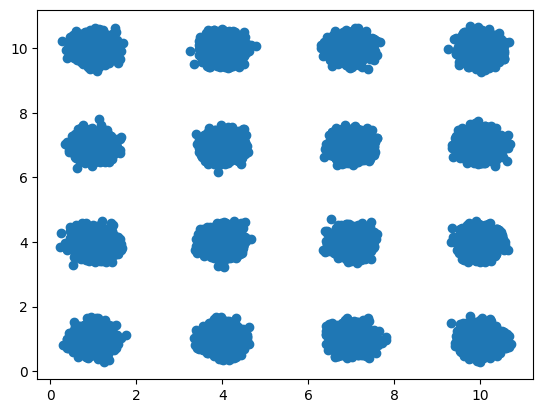

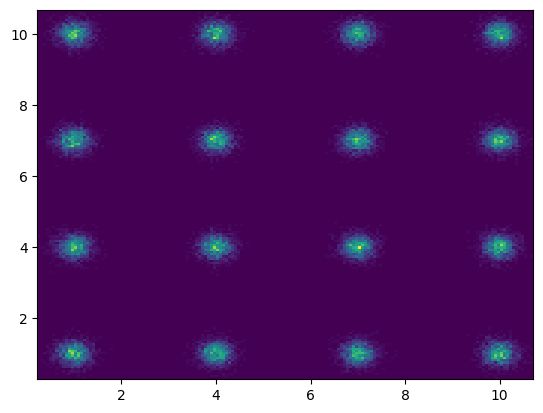

In [5]:
def generate_sphere(k, n_per_k, mu_0=1, mu_1=5, sigma = 1.0):
    mus = np.linspace(mu_0, mu_1, k)
    # sigma = (mu_1-mu_0)/(2*k)
    # if sigma > 1.0: sigma = 1.0 
    x = np.array([])
    y = np.array([])
    for mu in mus:
        for mu2 in mus:
            x = np.concatenate((x, mu + sigma*np.random.randn(n_per_k))) 
            y = np.concatenate((y, mu2 + sigma*np.random.randn(n_per_k)))
    return np.concatenate((np.expand_dims(x,axis=1),np.expand_dims(y,axis=1)), axis=1)
data = generate_sphere(4, 2000, 1.0, 5.0, 0.2)

data = generate_sphere(4, 2000, 1.0, 10.0, 0.2)
plt.scatter(data[:,0],data[:,1])
plt.show()
plt.hist2d(data[:,0],data[:,1], bins=164)
plt.show()


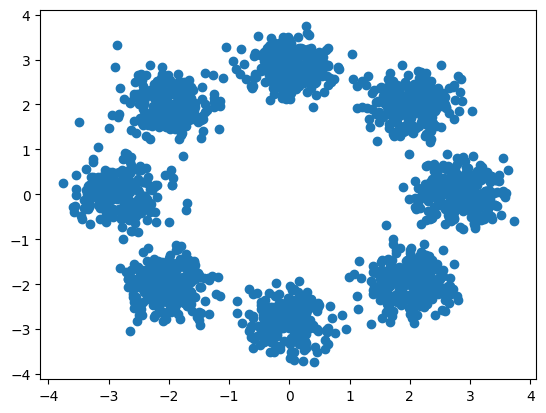

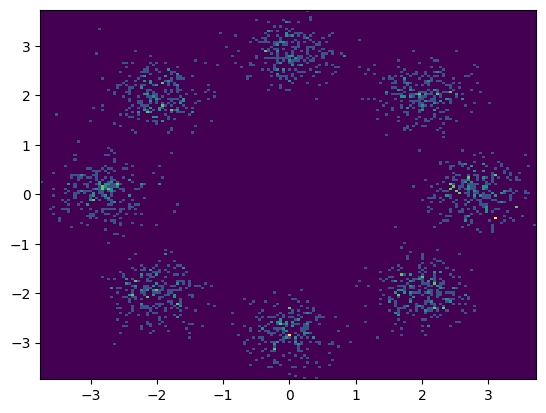

In [6]:
def gen_data(n: int):
    scale = 4.
    centers = torch.tensor([
        [1, 0],
        [-1, 0],
        [0, 1],
        [0, -1],
        [1. / np.sqrt(2), 1. / np.sqrt(2)],
        [1. / np.sqrt(2), -1. / np.sqrt(2)],
        [-1. / np.sqrt(2), 1. / np.sqrt(2)],
        [-1. / np.sqrt(2), -1. / np.sqrt(2)]
    ], dtype=torch.float32)
    centers = scale * centers

    x = torch.randn(n, 2)
    x = 0.5 * x

    center_ids = torch.randint(0, 8, (n,))
    x = x + centers[center_ids]

    x = x / 2 ** 0.5

    return x

data = gen_data(2000).cpu().numpy()
plt.scatter(data[:,0],data[:,1])
plt.show()
plt.hist2d(data[:,0],data[:,1], bins=164)
plt.show()

C:\Users\dokug\OneDrive - The University of Manchester\PhD\coding\project\benchmarks\tabsyn\baselines\tabvvfm2
device used: cuda


100%|█████████████████████████████████████████████████████████████████████████████████| 2500/2500 [15:42<00:00,  2.65it/s]


execution time: 945.6125059127808 seconds or approx. 16.0 minutes


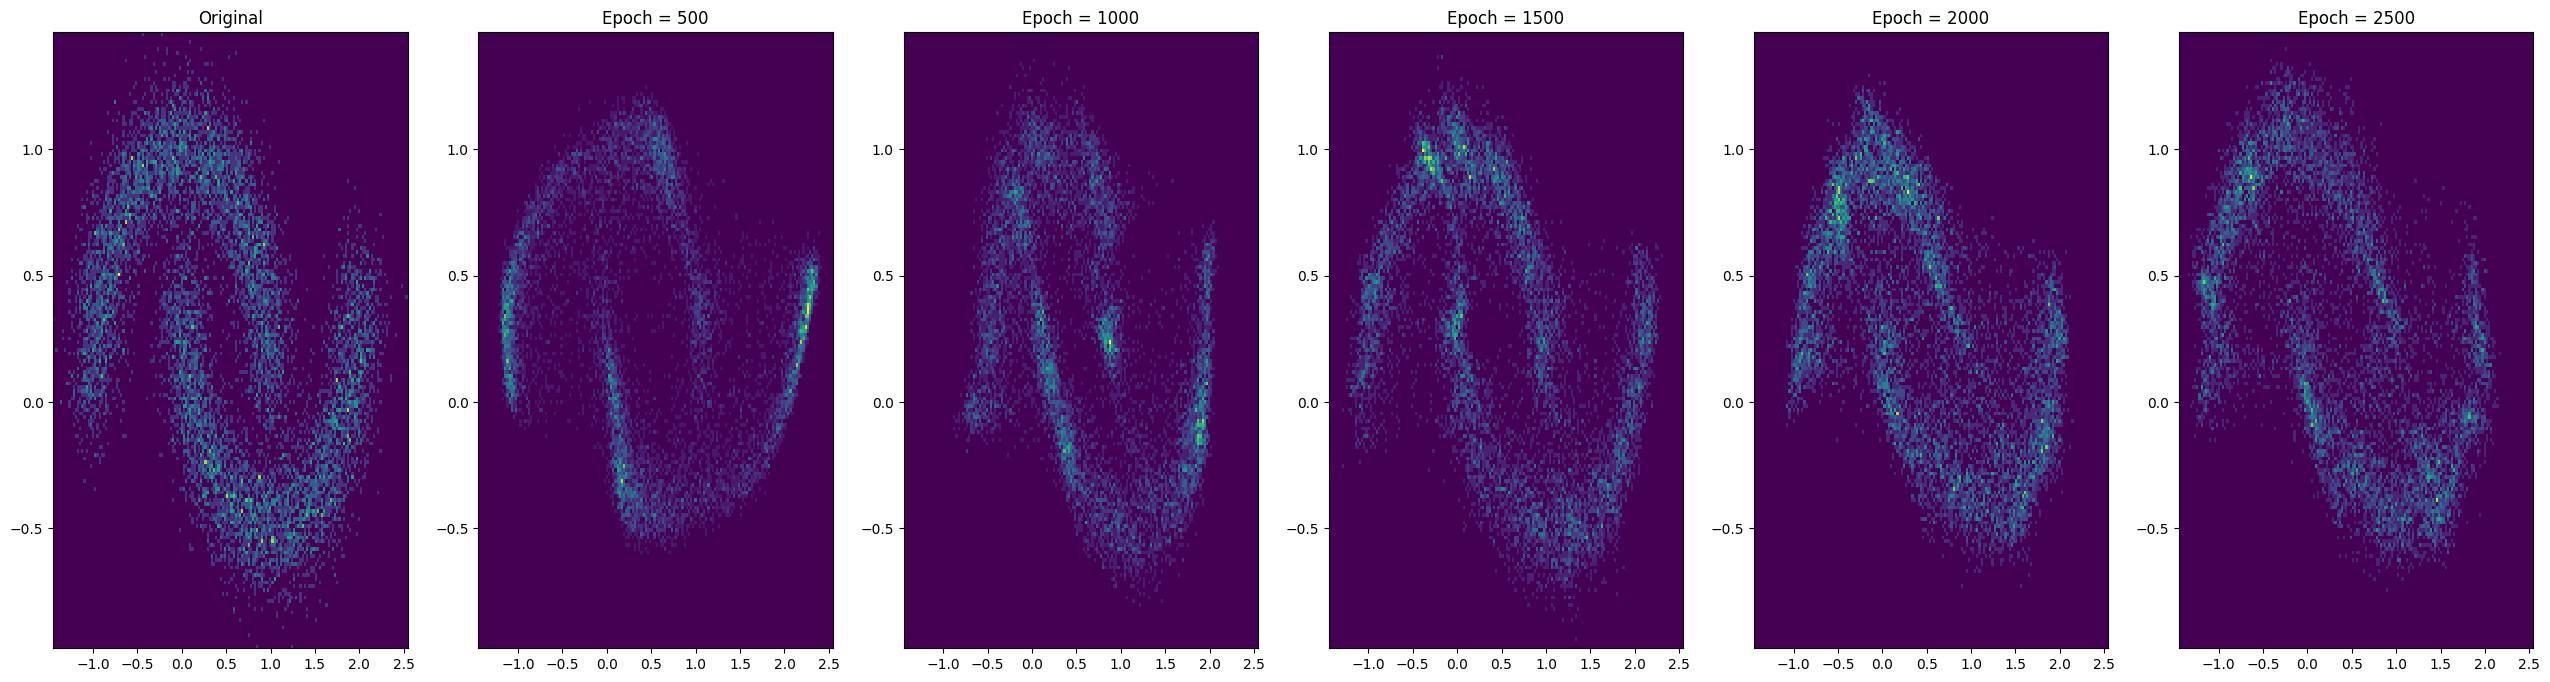

In [7]:
start = time()

init_dir = os.getcwd()

if not torch.cuda.is_available():
    device = 'cpu'
else:
    device = 'cuda'

print(init_dir)
print('device used: '+device)

def get_data(dataset: str, n_points: int) -> np.ndarray:
  if dataset == "moons":
    data, _ = make_moons(n_points, noise=0.15)
  elif dataset == "swiss":
    data, _ = make_swiss_roll(n_points, noise=0.25)
    data = data[:, [0, 2]] / 10.0
  return data

n_points = 10000
DATASET = "moons"

## generate sphere data
data1 = get_data(DATASET, n_points)
x_min = data1[:, 0].min()  # Minimum value for the x-axis (based on the first column of x)
x_max = data1[:, 0].max()  # Maximum value for the x-axis (based on the first column of x)

y_min = data1[:, 1].min()  # Minimum value for the y-axis (based on the second column of x)
y_max = data1[:, 1].max()  # Maximum value for the y-axis (based on the second column of x)
x_range = [x_min, x_max]  # Range for the x-axis bins
y_range = [y_min, y_max]  # Range for the y-axis bins

# data1 = generate_sphere(4, 625, 1.0, 10.0, 0.2)
# data1 = gen_data(10000).cpu().numpy()
scaler = StandardScaler()
# scaler = QuantileTransformer()
data = scaler.fit_transform(data1)

np.random.seed(42)
delu.random.seed(42)
'''We then transform the data points into a pytorch.utils.data.DataLoader to facilitate data handling. We set the batch_size to  512 .'''

batch_size = 2048
dataset = torch.from_numpy(data).float()
dataset = dataset
dataset = TensorDataset(dataset)
dataloader = DataLoader(dataset, batch_size=batch_size)

'''
    This is the training phase, current example is a simple OT FM,
    the details are in
    https://github.com/gle-bellier/flow-matching/blob/main/Flow_Matching.ipynb
    or in the flow matching notebook in drive
   '''

def sampling_plot(epoch):
    # Sampling
    v_t.eval()
    n_samples = 10_000
    with torch.no_grad():
        x_0 = torch.randn(n_samples, 2, device=device)
        x_1_hat = v_t.decode(x_0)

    ### Last, we plot the samples $\hat{x}_1$ distribution:
    v_t.train()
    x_1_hat = x_1_hat.cpu().numpy()
    return scaler.inverse_transform(x_1_hat)
    # plt.hist2d(x_1_hat[:, 0], x_1_hat[:, 1], bins=164)
    # plt.savefig(f'{init_dir}/img/img_sample_{epoch}.png')
    # plt.show()

d_cont = 2
d_total = 2

model = TabFlowMatching(d_cont, None)
net = Net(d_total, 512).to(device)
net_t = OT_t().to(device)
# net_t = VPDiffusion_t().to(device)
v_t = CondVF(net, net_t, d_cont = d_cont, cat_list = None)

losses = []
# configure optimizer
optimizer = torch.optim.Adam(v_t.parameters(), lr=1e-3)
n_epochs = 2500
every = 500
n_plots = (n_epochs//every) + 2 if n_epochs%every != 0 else n_epochs//every + 1
figure, axis = plt.subplots(1, n_plots, figsize=(32, 8))

axis[0].hist2d(data1[:, 0], data1[:, 1], bins=164,range=[x_range, y_range])
axis[0].set_title(f'Original')
# # epoch_iterator = tqdm(range(n_times))

for epoch in tqdm(range(n_epochs)):
    for batch in dataloader:
        optimizer.zero_grad()
        x_1 = batch[0].to(device)
        # compute loss
        loss = model.loss(v_t, x_1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(v_t.parameters(), 1.0)
        optimizer.step()
        losses += [[epoch, loss.detach().cpu().numpy()]]
    if (epoch + 1)%every == 0 or (epoch + 1) == n_epochs:
        x_1_hat = sampling_plot(epoch+1)
        id1 = ((epoch + 1)//every) if (epoch + 1)%every == 0 else ((epoch + 1)//every) + 1
        axis[id1].hist2d(x_1_hat[:, 0], x_1_hat[:, 1], bins=164, range=[x_range, y_range])
        axis[id1].set_title(f'Epoch = {epoch+1}')

end = time()
diff_t = end - start
total_t = (diff_t//60) + 1
print(f'execution time: {str(diff_t)} seconds or approx. {str(total_t)} minutes')
plt.show()

In [8]:
aa = pd.DataFrame(losses)
ab = aa.groupby(0).mean()
ab

,1
0,
0,1.17213
1,0.732399
2,0.696622
3,0.616575
4,0.578127
...,...
2495,0.481078
2496,0.487158
2497,0.477129


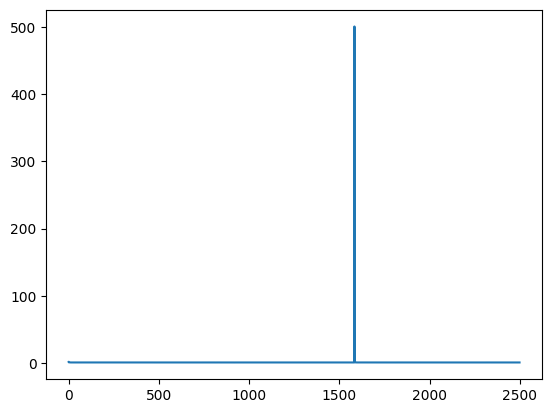

In [9]:
plt.plot(range(len(ab)), ab[1].values)